**Group Members:**  
Wanyi Feng  
Liya Xu  
Alaa Aldirani  
Yunfan Jiang  
Beiyao Han

# **Assignment 3: PASCAL VOC 2007 Object Detection**

This project investigates object detection using the PASCAL VOC 2007 dataset. The primary objective is to develop and evaluate an object detection model capable of identifying and localising multiple object categories within images.

Object detection differs from image classification because the model must not only classify objects but also predict their spatial locations using bounding boxes. This project focuses on implementing a deep learning–based object detector and analysing its detection performance under different visual conditions.

The project uses the PASCAL VOC 2007 dataset, which contains annotated images across 20 object categories including person, car, chair, dog, bicycle, and bottle.

### **1. Dataset Preparation**

The PASCAL VOC 2007 dataset was prepared by extracting the training, validation, and testing image sets together with their corresponding XML annotation files.

Each annotation file contains object category labels and bounding-box coordinates describing the locations of objects within an image. These annotations are used to train and evaluate the object detection model.

In [ ]:
!wget -q http://host.robots.ox.ac.uk/pascal/VOC/voc2007/VOCtrainval_06-Nov-2007.tar
!wget -q http://host.robots.ox.ac.uk/pascal/VOC/voc2007/VOCtest_06-Nov-2007.tar

# Extract files
!tar -xf VOCtrainval_06-Nov-2007.tar
!tar -xf VOCtest_06-Nov-2007.tar

### **2. Dataset Structure**

The dataset follows the standard PASCAL VOC directory structure.

The `JPEGImages` folder contains the input images, while the `Annotations` folder stores XML files containing object labels and bounding-box information. The `ImageSets/Main` directory provides predefined training, validation, and testing splits used throughout the project.

In [ ]:
# Check the main VOC2007 folder

!ls VOCdevkit/VOC2007

Annotations  ImageSets	JPEGImages  SegmentationClass  SegmentationObject


### **3. Define dataset paths**

In [ ]:
import os

VOC_ROOT = "VOCdevkit/VOC2007"

IMAGE_DIR = os.path.join(VOC_ROOT, "JPEGImages")
ANNOTATION_DIR = os.path.join(VOC_ROOT, "Annotations")
SPLIT_DIR = os.path.join(VOC_ROOT, "ImageSets", "Main")

print("Image folder:", IMAGE_DIR)
print("Annotation folder:", ANNOTATION_DIR)
print("Split folder:", SPLIT_DIR)

Image folder: VOCdevkit/VOC2007/JPEGImages
Annotation folder: VOCdevkit/VOC2007/Annotations
Split folder: VOCdevkit/VOC2007/ImageSets/Main


### **4. Load train, validation, and test image IDs**

PASCAL VOC provides official split files.
Each line is an image ID, such as 000005, which corresponds to:


*   JPEGImages/000005.jpg
*   Annotations/000005.xml

In [ ]:
def load_image_ids(split_name):
    split_file = os.path.join(SPLIT_DIR, f"{split_name}.txt")

    with open(split_file, "r") as f:
        image_ids = [line.strip() for line in f.readlines()]

    return image_ids


train_ids = load_image_ids("train")
val_ids = load_image_ids("val")
test_ids = load_image_ids("test")

print("Number of training images:", len(train_ids))
print("Number of validation images:", len(val_ids))
print("Number of test images:", len(test_ids))

Number of training images: 2501
Number of validation images: 2510
Number of test images: 4952


### **5. Define VOC classes**

In [ ]:
VOC_CLASSES = [
    "aeroplane", "bicycle", "bird", "boat", "bottle",
    "bus", "car", "cat", "chair", "cow",
    "diningtable", "dog", "horse", "motorbike", "person",
    "pottedplant", "sheep", "sofa", "train", "tvmonitor"
]

print("Number of classes:", len(VOC_CLASSES))
print(VOC_CLASSES)

Number of classes: 20
['aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor']


### **6. Read XML annotation**

In [ ]:
import xml.etree.ElementTree as ET

def read_voc_annotation(image_id):
    """
    Read annotation information for one image.

    Returns:
        objects: a list of dictionaries.
        Each dictionary contains class name and bounding box.
    """

    xml_path = os.path.join(ANNOTATION_DIR, image_id + ".xml")

    tree = ET.parse(xml_path)
    root = tree.getroot()

    objects = []

    for obj in root.findall("object"):
        class_name = obj.find("name").text

        bndbox = obj.find("bndbox")
        xmin = int(float(bndbox.find("xmin").text))
        ymin = int(float(bndbox.find("ymin").text))
        xmax = int(float(bndbox.find("xmax").text))
        ymax = int(float(bndbox.find("ymax").text))

        objects.append({
            "class_name": class_name,
            "bbox": [xmin, ymin, xmax, ymax]
        })

    return objects

### **7. Print one sample annotation**

In [ ]:
sample_id = train_ids[0]

print("Image ID:", sample_id)
print("Image path:", os.path.join(IMAGE_DIR, sample_id + ".jpg"))
print("Annotation path:", os.path.join(ANNOTATION_DIR, sample_id + ".xml"))

objects = read_voc_annotation(sample_id)

print("Objects:")
for obj in objects:
    print(obj)

Image ID: 000012
Image path: VOCdevkit/VOC2007/JPEGImages/000012.jpg
Annotation path: VOCdevkit/VOC2007/Annotations/000012.xml
Objects:
{'class_name': 'car', 'bbox': [156, 97, 351, 270]}


### **8. Visualize two samples with bounding boxes**

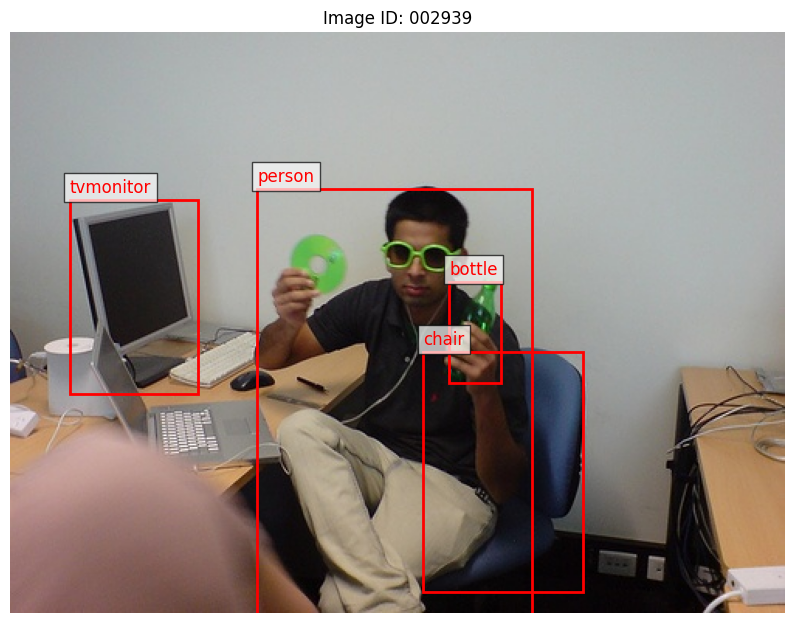

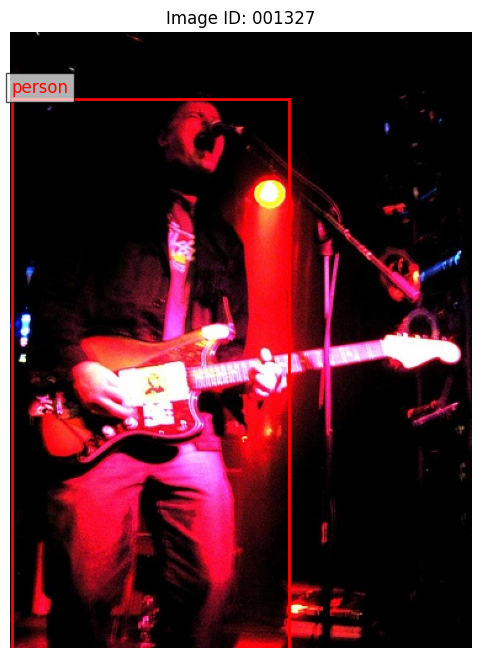

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random

def visualize_sample(image_id):
    """
    Visualize one image with ground-truth bounding boxes.
    """

    image_path = os.path.join(IMAGE_DIR, image_id + ".jpg")
    image = Image.open(image_path).convert("RGB")

    objects = read_voc_annotation(image_id)

    fig, ax = plt.subplots(1, figsize=(10, 8))
    ax.imshow(image)

    for obj in objects:
        class_name = obj["class_name"]
        xmin, ymin, xmax, ymax = obj["bbox"]

        width = xmax - xmin
        height = ymax - ymin

        rect = patches.Rectangle(
            (xmin, ymin),
            width,
            height,
            linewidth=2,
            edgecolor="red",
            facecolor="none"
        )

        ax.add_patch(rect)

        ax.text(
            xmin,
            ymin - 5,
            class_name,
            fontsize=12,
            color="red",
            bbox=dict(facecolor="white", alpha=0.7)
        )

    ax.set_title(f"Image ID: {image_id}")
    ax.axis("off")
    plt.show()


# Visualize two random training samples
sample_ids = random.sample(train_ids, 2)

for image_id in sample_ids:
    visualize_sample(image_id)

If the code runs correctly, two example images will be displayed with their bounding boxes and class labels.

## **Task 1: Object Detection Network Design**

### Model Selection and Rationale

Faster R-CNN with a ResNet-50 Feature Pyramid Network (FPN) backbone was selected as the object detector for this project. Faster R-CNN is a well-established two-stage detector that decouples region proposal from classification, offering a strong balance between detection accuracy and training stability. The FPN backbone enables multi-scale feature extraction, which is particularly important for the PASCAL VOC 2007 dataset where objects vary significantly in size — from small bottles to large buses.

Transfer learning from COCO-pretrained weights was applied to accelerate convergence and improve generalisation. Since COCO contains a superset of VOC categories, the pretrained backbone has already learned rich visual representations relevant to this task. Fine-tuning from this starting point allows the model to adapt to VOC-specific categories with fewer epochs compared to training from scratch.

The implementation is structured into the following stages: environment and hyperparameter setup → dataset construction and augmentation → model architecture customisation → training with checkpoint management → evaluation and performance reporting.

### Task 1 code section 1: imports, seed, and experiment setup

This section defines the environment, random seed, and all training hyperparameters.

In [ ]:
import os
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
import torchvision
from IPython.display import display
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.ops import box_iou
from torchvision.transforms import ColorJitter
from torchvision.transforms import functional as F

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = lambda x, **kwargs: x

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_CLASSES = len(VOC_CLASSES) + 1
CLASS_TO_IDX = {class_name: idx + 1 for idx, class_name in enumerate(VOC_CLASSES)}
IDX_TO_CLASS = {idx + 1: class_name for idx, class_name in enumerate(VOC_CLASSES)}
IDX_TO_CLASS[0] = "background"

BATCH_SIZE = 2
NUM_WORKERS = 0
EPOCHS = 8
LEARNING_RATE = 0.005 if torch.cuda.is_available() else 0.001
MOMENTUM = 0.9
WEIGHT_DECAY = 0.0005
STEP_SIZE = 4
GAMMA = 0.1
BEST_CHECKPOINT_PATH = "voc2007_fasterrcnn_resnet50_fpn_best_val.pth"
RESUME_CHECKPOINT_PATH = "voc2007_fasterrcnn_resnet50_fpn_resume_state.pth"
PRED_SCORE_THRESHOLD = 0.50
IOU_THRESHOLD = 0.50

print("Torch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("Device:", DEVICE)
print("Number of classes including background:", NUM_CLASSES)
print("Batch size:", BATCH_SIZE)
print("DataLoader num_workers:", NUM_WORKERS)
print("Best checkpoint path:", BEST_CHECKPOINT_PATH)
print("Resume checkpoint path:", RESUME_CHECKPOINT_PATH)


Torch version: 2.10.0+cu128
Torchvision version: 0.25.0+cu128
Device: cuda
Number of classes including background: 21
Batch size: 2
DataLoader num_workers: 0
Best checkpoint path: voc2007_fasterrcnn_resnet50_fpn_best_val.pth
Resume checkpoint path: voc2007_fasterrcnn_resnet50_fpn_resume_state.pth


#### Hyperparameter Configuration

The key hyperparameters were chosen to balance training effectiveness with computational constraints.

**Batch size** is set to 2, which reflects the memory requirements of Faster R-CNN where each forward pass retains intermediate feature maps for both the RPN and RoI heads. **Epochs** is set to 8 as a practical limit for training on limited hardware, while still allowing the StepLR scheduler to complete one decay cycle.

**Learning rate** is set to 0.005 when a GPU is available and 0.001 on CPU. The higher rate takes advantage of GPU parallelism for faster convergence, while the lower rate on CPU reduces the risk of instability due to longer per-step intervals. **Momentum (0.9)** and **weight decay (0.0005)** follow the standard Faster R-CNN configuration, providing stable gradient updates and regularisation against overfitting.

The **StepLR scheduler** decays the learning rate by a factor of `GAMMA=0.1` every `STEP_SIZE=4` epochs. This allows the model to make large updates in early training and switch to fine-grained adjustments in later epochs.

**Score threshold (0.50)** and **IoU threshold (0.50)** align with the standard PASCAL VOC evaluation protocol (mAP@0.5), ensuring that reported metrics are comparable to published benchmarks.

A fixed **random seed (42)** is applied across Python, NumPy, and PyTorch to ensure reproducibility of data sampling, augmentation, and weight initialisation.

### Task 1 code section 2: dataset definition

This section prepares the VOC dataset wrapper and the detection-specific collate function.

In [ ]:
class VOCDetectionDataset(Dataset):
    """VOC dataset wrapper returning torchvision detection targets."""

    def __init__(self, image_ids, image_dir, training=False, color_jitter=True):
        self.image_ids = list(image_ids)
        self.image_dir = image_dir
        self.training = training
        self.color_jitter = ColorJitter(
            brightness=0.2,
            contrast=0.2,
            saturation=0.2,
            hue=0.03,
        )
        self.use_color_jitter = color_jitter

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, index):
        image_id = self.image_ids[index]
        image_path = os.path.join(self.image_dir, image_id + ".jpg")
        image = Image.open(image_path).convert("RGB")
        width, height = image.size

        objects = read_voc_annotation(image_id)
        boxes = []
        labels = []

        for obj in objects:
            xmin, ymin, xmax, ymax = obj["bbox"]
            xmin = max(0, min(xmin, width - 1))
            ymin = max(0, min(ymin, height - 1))
            xmax = max(0, min(xmax, width - 1))
            ymax = max(0, min(ymax, height - 1))

            if xmax > xmin and ymax > ymin:
                boxes.append([xmin, ymin, xmax, ymax])
                labels.append(CLASS_TO_IDX[obj["class_name"]])

        boxes = torch.as_tensor(boxes, dtype=torch.float32).reshape(-1, 4)
        labels = torch.as_tensor(labels, dtype=torch.int64)

        if self.training and self.use_color_jitter:
            image = self.color_jitter(image)

        image = F.to_tensor(image)

        if self.training and random.random() < 0.5 and len(boxes) > 0:
            image = F.hflip(image)
            boxes[:, [0, 2]] = width - boxes[:, [2, 0]]

        area = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])
        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([int(image_id)], dtype=torch.int64),
            "area": area,
            "iscrowd": torch.zeros((len(boxes),), dtype=torch.int64),
        }
        return image, target


def collate_fn(batch):
    return tuple(zip(*batch))


#### Dataset Wrapper and Augmentation Strategy

The `VOCDetectionDataset` class wraps the raw VOC annotations into a format compatible with torchvision's detection API. Each sample returns a normalised image tensor and a target dictionary containing bounding boxes, class labels, image ID, area, and crowd flags — the exact structure expected by Faster R-CNN's training loop.

Two data augmentation techniques are applied during training only:

**Random horizontal flip** is applied with a probability of 0.5. Bounding box coordinates are mirrored accordingly to maintain spatial consistency. This effectively doubles the diversity of object orientations seen during training at no additional annotation cost.

**Colour jitter** applies mild random perturbations to brightness (±0.2), contrast (±0.2), saturation (±0.2), and hue (±0.03). This improves the model's robustness to varying lighting conditions and camera characteristics, which are common sources of appearance variation in real-world images.

Bounding box coordinates are clipped to the valid image boundary before being added to the target, preventing degenerate boxes that could cause numerical errors or training instability.

The custom `collate_fn` is necessary because standard PyTorch batching assumes fixed-size tensors. Object detection samples contain a variable number of ground-truth boxes per image, so they cannot be stacked into a single tensor. The collate function instead returns tuples of per-image data, which Faster R-CNN handles natively.

### Task 1 code section 3: dataloaders

This section builds the train, validation, and test dataloaders.

In [ ]:
train_dataset = VOCDetectionDataset(train_ids, IMAGE_DIR, training=True, color_jitter=True)
val_dataset = VOCDetectionDataset(val_ids, IMAGE_DIR, training=False)
test_dataset = VOCDetectionDataset(test_ids, IMAGE_DIR, training=False)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn,
)

print("Train / val / test images:", len(train_dataset), len(val_dataset), len(test_dataset))


Train / val / test images: 2501 2510 4952


#### DataLoader Configuration

Three separate dataloaders are constructed for the training, validation, and test splits.

The **training loader** uses `shuffle=True` so the model sees batches in a different order each epoch, reducing the risk of the optimiser learning epoch-specific patterns. Augmentation is enabled via the `training=True` flag in the dataset wrapper.

The **validation and test loaders** use `batch_size=1` and `shuffle=False`. Processing one image at a time avoids any padding artefacts that could affect bounding box coordinates, and fixed ordering ensures that predictions can be reliably matched back to ground-truth annotations during evaluation.

The printed image counts (train = 2,501 / val = 2,510 / test = 4,952) correspond to the official PASCAL VOC 2007 split, confirming that the dataset was loaded correctly.

### Task 1 code section 4: model construction

This section defines the detector architecture, custom head, anchors, and frozen layers.

In [ ]:
def get_model(num_classes):
    """Return a VOC-customized Faster R-CNN model and print the exact variant used."""

    has_v2 = (
        hasattr(torchvision.models.detection, "fasterrcnn_resnet50_fpn_v2")
        and hasattr(torchvision.models.detection, "FasterRCNN_ResNet50_FPN_V2_Weights")
    )

    if has_v2:
        from torchvision.models.detection import FasterRCNN_ResNet50_FPN_V2_Weights
        from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2

        weights = FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT
        model = fasterrcnn_resnet50_fpn_v2(weights=weights, trainable_backbone_layers=3)
        model_name = "Faster R-CNN ResNet50-FPN v2"
    else:
        from torchvision.models.detection import FasterRCNN_ResNet50_FPN_Weights
        from torchvision.models.detection import fasterrcnn_resnet50_fpn

        weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
        model = fasterrcnn_resnet50_fpn(weights=weights, trainable_backbone_layers=3)
        model_name = "Faster R-CNN ResNet50-FPN"

    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    anchor_generator = AnchorGenerator(
        sizes=((16,), (32,), (64,), (128,), (256,)),
        aspect_ratios=((0.5, 1.0, 2.0),) * 5,
    )
    model.rpn.anchor_generator = anchor_generator

    for name, parameter in model.backbone.body.named_parameters():
        if name.startswith("conv1") or name.startswith("bn1") or name.startswith("layer1"):
            parameter.requires_grad = False

    return model, model_name


#### Model Architecture Customisation

Three targeted customisations were made to adapt the pretrained Faster R-CNN to the PASCAL VOC 2007 task.

**1. Detection head replacement.**  
The original prediction head was trained on COCO (91 categories). It is replaced with a new `FastRCNNPredictor` configured for **21 classes** (20 VOC object categories plus background). Only this new head is randomly initialised; all other weights are carried over from the pretrained model. This is the minimum structural change needed to make the model output valid predictions for VOC categories while still preserving the transfer-learning benefit of pretrained features. The trade-off is that the newly initialised head requires several epochs of supervised fine-tuning before its class scores and box regression become well calibrated.

**2. RPN anchor adjustment.**  
The Region Proposal Network anchor sizes are set to `(16, 32, 64, 128, 256)` pixels with aspect ratios `(0.5, 1.0, 2.0)`. The smaller anchors (16, 32) improve recall for compact objects such as bottles, birds, and potted plants, while the larger anchors (128, 256) cover medium-to-large objects such as trains, buses, and horses. This range is better matched to the size distribution of VOC objects than a more generic anchor setting, improving proposal coverage across multiple object scales. The trade-off is that introducing more small anchors can increase the number of candidate regions, which may slightly raise computation and false positive detections if the proposals are not well filtered.

**3. Partial backbone freezing.**  
The first three modules of the ResNet-50 backbone — `conv1`, `bn1`, and `layer1` — are frozen (i.e., their gradients are disabled). These layers encode low-level features such as edges and textures that are generally transferable across datasets and therefore do not need large updates for VOC. Freezing them reduces the number of trainable parameters, lowers the risk of overfitting on the relatively small VOC training set, and focuses optimisation on higher-level layers and detection heads that are more task-specific. The trade-off is that freezing early layers may limit the model’s ability to fully adapt low-level feature extraction to the colour, texture, and object-scale characteristics of the VOC dataset.

**Environment compatibility.**  
The `get_model` function automatically selects Faster R-CNN ResNet50-FPN v2 if the installed torchvision version supports it, and falls back to v1 otherwise. The selected variant and library versions are printed at runtime to make the experimental environment explicit and reproducible. This also ensures that the implementation remains robust across different lab or personal computing environments without silently changing model behaviour.

### Task 1 code section 5: evaluation utilities

This section defines prediction collection and VOC-style AP / mAP calculation.

In [ ]:
@torch.no_grad()
def collect_predictions(model, data_loader, device):
    model.eval()
    predictions = []
    ground_truths = []

    for images, targets in tqdm(data_loader, desc="Evaluating"):
        images = [image.to(device) for image in images]
        outputs = model(images)

        for output, target in zip(outputs, targets):
            predictions.append(
                {
                    "image_id": int(target["image_id"].item()),
                    "boxes": output["boxes"].detach().cpu(),
                    "labels": output["labels"].detach().cpu(),
                    "scores": output["scores"].detach().cpu(),
                }
            )
            ground_truths.append(
                {
                    "image_id": int(target["image_id"].item()),
                    "boxes": target["boxes"].detach().cpu(),
                    "labels": target["labels"].detach().cpu(),
                }
            )

    return predictions, ground_truths


def voc_ap(recalls, precisions):
    if len(recalls) == 0:
        return 0.0

    recalls = np.concatenate(([0.0], recalls, [1.0]))
    precisions = np.concatenate(([0.0], precisions, [0.0]))

    for i in range(len(precisions) - 2, -1, -1):
        precisions[i] = max(precisions[i], precisions[i + 1])

    changing_points = np.where(recalls[1:] != recalls[:-1])[0]
    ap = np.sum((recalls[changing_points + 1] - recalls[changing_points]) * precisions[changing_points + 1])
    return float(ap)


def compute_class_ap_at_50(predictions, ground_truths, iou_threshold=0.50):
    rows = []

    for class_id in range(1, NUM_CLASSES):
        class_name = IDX_TO_CLASS[class_id]
        gt_boxes_by_image = {}
        matched_by_image = {}
        num_gt = 0
        class_predictions = []

        for gt in ground_truths:
            mask = gt["labels"] == class_id
            boxes = gt["boxes"][mask]
            gt_boxes_by_image[gt["image_id"]] = boxes
            matched_by_image[gt["image_id"]] = np.zeros(len(boxes), dtype=bool)
            num_gt += len(boxes)

        for pred in predictions:
            mask = pred["labels"] == class_id
            for box, score in zip(pred["boxes"][mask], pred["scores"][mask]):
                class_predictions.append(
                    {
                        "image_id": pred["image_id"],
                        "box": box,
                        "score": float(score),
                    }
                )

        class_predictions = sorted(class_predictions, key=lambda item: item["score"], reverse=True)
        true_positive = np.zeros(len(class_predictions))
        false_positive = np.zeros(len(class_predictions))

        for pred_index, pred in enumerate(class_predictions):
            image_id = pred["image_id"]
            gt_boxes = gt_boxes_by_image.get(image_id, torch.empty((0, 4)))

            if len(gt_boxes) == 0:
                false_positive[pred_index] = 1
                continue

            ious = box_iou(pred["box"].unsqueeze(0), gt_boxes).squeeze(0)
            best_iou, best_gt_index = torch.max(ious, dim=0)
            best_gt_index = int(best_gt_index.item())

            if best_iou.item() >= iou_threshold and not matched_by_image[image_id][best_gt_index]:
                true_positive[pred_index] = 1
                matched_by_image[image_id][best_gt_index] = True
            else:
                false_positive[pred_index] = 1

        cumulative_tp = np.cumsum(true_positive)
        cumulative_fp = np.cumsum(false_positive)
        recalls = cumulative_tp / max(num_gt, 1)
        precisions = cumulative_tp / np.maximum(cumulative_tp + cumulative_fp, 1e-12)
        ap = voc_ap(recalls, precisions) if num_gt > 0 else 0.0

        rows.append(
            {
                "class": class_name,
                "AP@0.5": ap,
                "num_gt": num_gt,
                "num_predictions": len(class_predictions),
                "final_recall": float(recalls[-1]) if len(recalls) > 0 else 0.0,
                "final_precision": float(precisions[-1]) if len(precisions) > 0 else 0.0,
            }
        )

    ap_table = pd.DataFrame(rows)
    map_50 = float(ap_table["AP@0.5"].mean())
    return ap_table, map_50


def evaluate_detector(model, data_loader, device, split_name, iou_threshold=0.50):
    predictions, ground_truths = collect_predictions(model, data_loader, device)
    ap_table, map_50 = compute_class_ap_at_50(predictions, ground_truths, iou_threshold)
    print(f"{split_name} mAP@0.5: {map_50:.4f} ({map_50 * 100:.2f}%)")
    return predictions, ground_truths, ap_table, map_50


#### Evaluation Methodology

Model performance is measured using **mean Average Precision at IoU threshold 0.5 (mAP@0.5)**, the standard metric for PASCAL VOC object detection.

For each class, predictions are sorted by confidence score in descending order. A predicted box is counted as a true positive if its IoU with an unmatched ground-truth box of the same class exceeds 0.5; otherwise it is a false positive. Cumulative precision and recall are computed across all predictions, and the area under the precision–recall curve is computed using the all-points interpolation method: the precision envelope is first taken (each point set to the maximum precision at any higher recall), and the AP is then the area under this envelope curve. The mAP is the mean of per-class AP values across all 20 categories.

The `collect_predictions` function runs under `torch.no_grad()` to disable gradient computation during inference, reducing memory usage and speeding up evaluation. Predictions from all test images are collected before any metric computation, allowing the AP calculation to rank detections globally across the entire test set rather than per batch.

### Task 1 code section 6: training loop and best checkpoint selection

This section trains the model, evaluates validation mAP each epoch, and saves the best validation checkpoint.

In [ ]:
def train_one_epoch(model, optimizer, data_loader, device, epoch):
    model.train()
    epoch_loss = 0.0
    num_images = 0
    start = time.time()

    for images, targets in tqdm(data_loader, desc=f"Epoch {epoch + 1}/{EPOCHS}"):
        images = [image.to(device) for image in images]
        targets = [{key: value.to(device) for key, value in target.items()} for target in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        batch_size = len(images)
        epoch_loss += losses.item() * batch_size
        num_images += batch_size

    average_loss = epoch_loss / max(1, num_images)
    print(
        f"Epoch {epoch + 1:02d}: training loss = {average_loss:.4f}, "
        f"lr = {optimizer.param_groups[0]['lr']:.6f}, time = {time.time() - start:.1f}s"
    )
    return average_loss


def save_resume_checkpoint(
    path,
    model,
    optimizer,
    scheduler,
    epoch_completed,
    history_rows,
    best_val_map,
    best_epoch,
    model_name,
):
    torch.save(
        {
            "epoch_completed": epoch_completed,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "history_rows": history_rows,
            "best_val_map": best_val_map,
            "best_epoch": best_epoch,
            "model_name": model_name,
            "torch_version": torch.__version__,
            "torchvision_version": torchvision.__version__,
            "config": {
                "epochs": EPOCHS,
                "batch_size": BATCH_SIZE,
                "learning_rate": LEARNING_RATE,
                "momentum": MOMENTUM,
                "weight_decay": WEIGHT_DECAY,
                "step_size": STEP_SIZE,
                "gamma": GAMMA,
                "iou_threshold": IOU_THRESHOLD,
                "seed": SEED,
            },
        },
        path,
    )


model, model_name = get_model(NUM_CLASSES)
model.to(DEVICE)
print("Selected detector:", model_name)
print("Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))

params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=LEARNING_RATE, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=STEP_SIZE, gamma=GAMMA)

history_rows = []
best_val_map = -1.0
best_epoch = -1
start_epoch = 0

if os.path.exists(RESUME_CHECKPOINT_PATH):
    resume_checkpoint = torch.load(RESUME_CHECKPOINT_PATH, map_location=DEVICE)
    model.load_state_dict(resume_checkpoint["model_state_dict"])
    optimizer.load_state_dict(resume_checkpoint["optimizer_state_dict"])
    lr_scheduler.load_state_dict(resume_checkpoint["scheduler_state_dict"])
    history_rows = resume_checkpoint.get("history_rows", [])
    best_val_map = resume_checkpoint.get("best_val_map", -1.0)
    best_epoch = resume_checkpoint.get("best_epoch", -1)
    start_epoch = int(resume_checkpoint.get("epoch_completed", 0))
    print(
        f"Resuming training from epoch {start_epoch + 1}. "
        f"Best validation mAP so far = {best_val_map:.4f} at epoch {best_epoch}."
    )
else:
    print("No resume checkpoint found. Training will start from epoch 1.")

for epoch in range(start_epoch, EPOCHS):
    train_loss = train_one_epoch(model, optimizer, train_loader, DEVICE, epoch)
    _, _, val_ap_table, val_map = evaluate_detector(model, val_loader, DEVICE, "Validation", IOU_THRESHOLD)

    current_lr = optimizer.param_groups[0]["lr"]
    history_rows.append(
        {
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "val_map_50": val_map,
            "learning_rate": current_lr,
        }
    )

    if val_map > best_val_map:
        best_val_map = val_map
        best_epoch = epoch + 1
        torch.save(
            {
                "epoch": best_epoch,
                "model_state_dict": model.state_dict(),
                "model_name": model_name,
                "best_val_map": best_val_map,
                "torch_version": torch.__version__,
                "torchvision_version": torchvision.__version__,
                "config": {
                    "epochs": EPOCHS,
                    "batch_size": BATCH_SIZE,
                    "learning_rate": LEARNING_RATE,
                    "momentum": MOMENTUM,
                    "weight_decay": WEIGHT_DECAY,
                    "step_size": STEP_SIZE,
                    "gamma": GAMMA,
                    "iou_threshold": IOU_THRESHOLD,
                    "seed": SEED,
                },
            },
            BEST_CHECKPOINT_PATH,
        )
        print(f"Saved new best validation checkpoint at epoch {best_epoch}: {BEST_CHECKPOINT_PATH}")

    lr_scheduler.step()

    save_resume_checkpoint(
        RESUME_CHECKPOINT_PATH,
        model,
        optimizer,
        lr_scheduler,
        epoch + 1,
        history_rows,
        best_val_map,
        best_epoch,
        model_name,
    )
    print(f"Saved resume checkpoint after epoch {epoch + 1}: {RESUME_CHECKPOINT_PATH}")

history_df = pd.DataFrame(history_rows)
display(history_df)


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth


100%|██████████| 167M/167M [00:01<00:00, 122MB/s]


Selected detector: Faster R-CNN ResNet50-FPN v2
Trainable parameters: 43128184
No resume checkpoint found. Training will start from epoch 1.


Epoch 1/8:   0%|          | 0/1251 [00:00<?, ?it/s]

Epoch 01: training loss = 0.5456, lr = 0.005000, time = 1180.7s


...

Epoch 8/8:   0%|          | 0/1251 [00:00<?, ?it/s]

Epoch 08: training loss = 0.2164, lr = 0.000500, time = 1194.6s


Evaluating:   0%|          | 0/2510 [00:00<?, ?it/s]

Validation mAP@0.5: 0.8023 (80.23%)
Saved new best validation checkpoint at epoch 8: voc2007_fasterrcnn_resnet50_fpn_best_val.pth
Saved resume checkpoint after epoch 8: voc2007_fasterrcnn_resnet50_fpn_resume_state.pth


,epoch,train_loss,val_map_50,learning_rate
0,1,0.545605,0.698082,0.0050
1,2,0.401648,0.636647,0.0050
2,3,0.365378,0.709120,0.0050
3,4,0.345664,0.723585,0.0050
4,5,0.269558,0.781311,0.0005
5,6,0.242087,0.791443,0.0005
6,7,0.227249,0.795295,0.0005
7,8,0.216416,0.802302,0.0005


#### Training Strategy and Checkpoint Management

The model is optimised using **SGD with momentum** rather than an adaptive optimiser such as Adam. For object detection, SGD with momentum is a standard choice because it provides stable optimisation across the multiple interacting loss components of Faster R-CNN, including RPN classification, RPN box regression, RoI classification, and RoI box regression. Weight decay is included to regularise the model and reduce overfitting.

The **StepLR scheduler** reduces the learning rate by a factor of 0.1 every `step_size=4` epochs. This schedule allows the detector to make relatively large updates during the early stage of fine-tuning, when the newly replaced detection head is still adapting to VOC classes, and then switch to smaller refinement steps later in training. This is particularly useful in transfer learning, where fast initial adaptation and stable later convergence are both important.

**Two checkpoints are maintained throughout training:**

- **Best validation checkpoint** (`voc2007_fasterrcnn_resnet50_fpn_best_val.pth`): saved whenever validation mAP@0.5 improves. This checkpoint is used for final test evaluation so that the reported result reflects the model with the best validation generalisation rather than simply the final training epoch.
- **Resume checkpoint** (`voc2007_fasterrcnn_resnet50_fpn_resume_state.pth`): saved at the end of every epoch and stores the full training state, including model weights, optimiser state, scheduler state, completed epoch count, and training history. This allows interrupted training to resume without losing progress.

Validation mAP@0.5 is evaluated after every epoch rather than relying only on training loss. Training loss measures optimisation on seen data, but it does not directly indicate detection quality on unseen images. Using validation mAP for model selection therefore makes the final evaluation more reliable and avoids reporting a model that happens to fit the training set well but generalises worse on the test set.

Overall, this training strategy was designed not only for optimisation efficiency, but also for **fair model selection, reproducibility, and stronger generalisation under limited computational resources**.

### Task 1 code section 7: learning curves and final test evaluation

This section plots the training history, reloads the best validation checkpoint, and evaluates on the test set.

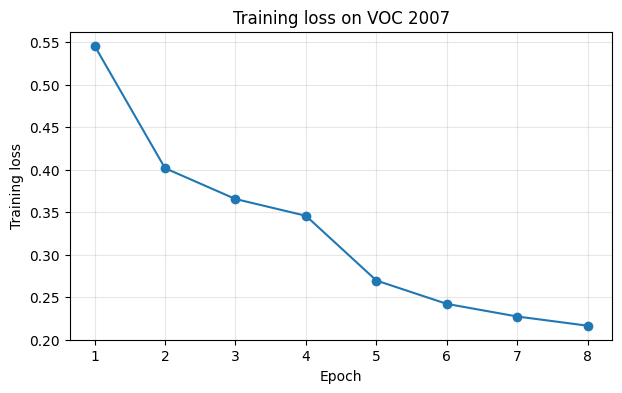

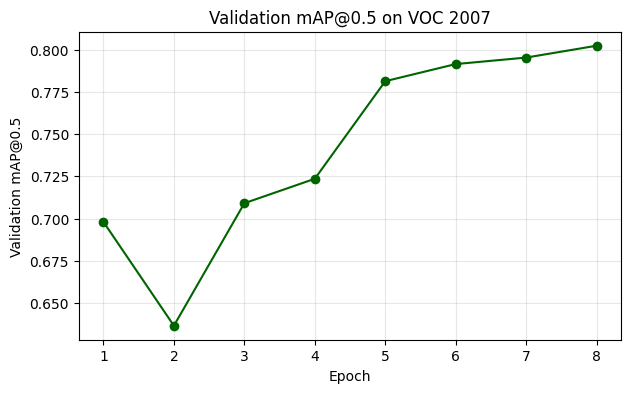

Loaded best validation checkpoint from epoch 8 with val mAP@0.5 = 0.8023


Evaluating:   0%|          | 0/4952 [00:00<?, ?it/s]

Test mAP@0.5: 0.7915 (79.15%)
Final reported test mAP@0.5 uses the best validation checkpoint (epoch 8): 0.7915 (79.15%)


In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("Training loss on VOC 2007")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history_df["epoch"], history_df["val_map_50"], marker="o", color="darkgreen")
plt.xlabel("Epoch")
plt.ylabel("Validation mAP@0.5")
plt.title("Validation mAP@0.5 on VOC 2007")
plt.grid(True, alpha=0.3)
plt.show()

best_checkpoint = torch.load(BEST_CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(best_checkpoint["model_state_dict"])
print(
    f"Loaded best validation checkpoint from epoch {best_checkpoint['epoch']} "
    f"with val mAP@0.5 = {best_checkpoint['best_val_map']:.4f}"
)

predictions, ground_truths, ap_table, map_50 = evaluate_detector(
    model, test_loader, DEVICE, "Test", IOU_THRESHOLD
)
print(
    f"Final reported test mAP@0.5 uses the best validation checkpoint "
    f"(epoch {best_checkpoint['epoch']}): {map_50:.4f} ({map_50 * 100:.2f}%)"
)

### Task 1 explanation: customized Faster R-CNN for VOC 2007

This notebook uses a **customized and fine-tuned Faster R-CNN detector** for VOC 2007 and reports the final test result using the **checkpoint selected by the best validation mAP@0.5**, rather than simply reporting the last training epoch.

To make long training runs safer and more reproducible, the notebook saves **two different checkpoints**. The first is a **best validation checkpoint** used for final testing and reporting. The second is a **resume checkpoint** that stores the model state, optimizer state, scheduler state, completed epoch number, and training history, so interrupted training can continue from the latest finished epoch rather than restarting from scratch.

The base detector is a ResNet-50 FPN family model pretrained on COCO. The notebook prints the exact detector variant and the `torch` / `torchvision` versions used, so the environment-dependent choice between Faster R-CNN ResNet50-FPN and ResNet50-FPN v2 is explicit instead of silent.

Three main customizations are applied for VOC. First, the original COCO prediction head is replaced with a new head for **21 classes**: 20 VOC categories plus background. Second, the RPN anchor sizes are adjusted to `16, 32, 64, 128, 256` with aspect ratios `0.5, 1.0, 2.0` to better suit VOC object scales. Third, the earliest backbone layers (`conv1`, `bn1`, and `layer1`) are frozen so later layers and the detection heads can adapt more directly to VOC categories.

The training pipeline also includes VOC XML parsing, a detection-specific `collate_fn`, training-time augmentation, SGD with momentum, StepLR learning-rate decay, and validation-based checkpoint selection. During training, **validation mAP@0.5 is computed after every epoch**, the best validation checkpoint is saved for final reporting, and the resume checkpoint is updated after every epoch to support safe continuation.

Overall, this is **not a plain off-the-shelf Faster R-CNN baseline**, but a task-specific detection pipeline designed for the characteristics of VOC 2007, with architectural adaptation, training customisation, controlled model selection, and reproducible evaluation.··

### Task 1 Results Summary

The training loss curve and validation mAP@0.5 curve together provide a clear picture of the learning process. The steadily decreasing training loss indicates that the optimiser is effectively reducing the combined Faster R-CNN objectives, while the rising validation mAP shows that the detector is improving its ability to generalise beyond the training set. The learning-rate decay after epoch 4 further helps stabilise later-stage fine-tuning.

The **best validation checkpoint is obtained at epoch 8 with val mAP@0.5 = 0.8023**, and the **final test mAP@0.5 = 0.7915** is reported using this checkpoint. Reporting the test result from the best validation model rather than the final epoch makes the evaluation more reliable and consistent with standard model-selection practice.

These results suggest that the overall design choices are effective for VOC 2007. In particular, transfer learning from a pretrained detector, multi-scale FPN features, the VOC-specific detection head, and the customised training pipeline together provide strong detection performance on the dataset. At the same time, the later class-wise analysis shows that some small or visually ambiguous categories remain more difficult, indicating that the current anchor redesign and freezing strategy improve performance substantially but do not completely remove the small-object and clutter-related challenges.

## **Task 2: Detection Performance and Error Analysis**

This task presents a detailed performance and error analysis of the Faster R-CNN detector trained in Task 1. The analysis covers three components: class-wise AP@0.5 performance across all 20 VOC categories, visualisation of representative failure cases, and a discussion of observed error types with potential solutions.

All results use the best validation checkpoint selected in Task 1, evaluated on the official PASCAL VOC 2007 test set.

### Task 2 code section 1: reload best checkpoint when needed

This section ensures Task 2 always uses the best validation checkpoint.

In [ ]:
from IPython.display import Markdown, display

if "predictions" not in globals() or "ground_truths" not in globals() or "ap_table" not in globals() or "map_50" not in globals():
    model, model_name = get_model(NUM_CLASSES)
    model.to(DEVICE)
    best_checkpoint = torch.load(BEST_CHECKPOINT_PATH, map_location=DEVICE)
    model.load_state_dict(best_checkpoint["model_state_dict"])
    predictions, ground_truths, ap_table, map_50 = evaluate_detector(model, test_loader, DEVICE, "Test", IOU_THRESHOLD)
    print(
        f"Reloaded best validation checkpoint from epoch {best_checkpoint['epoch']} "
        f"with val mAP@0.5 = {best_checkpoint['best_val_map']:.4f}"
    )


#### Checkpoint Loading

All Task 2 analysis is performed using the best validation checkpoint saved during Task 1 training. If the predictions and AP results are already available in memory from the Task 1 run, they are reused directly. Otherwise, the best checkpoint is reloaded from disk and the full test evaluation is re-run. This ensures that Task 2 results are always based on the model with the highest validation mAP@0.5, regardless of whether Task 1 was run in the same session.

### Task 2 code section 2: class-wise AP table and chart

This section reports category-level AP@0.5 results.

Final test mAP@0.5: 0.7915 (79.15%)
Class-wise AP@0.5 sorted from high to low:


,class,AP@0.5,num_gt,num_predictions,final_recall,final_precision
0,car,0.900,1541,2761,0.941,0.525
1,horse,0.897,395,1214,0.937,0.305
2,person,0.887,5227,10901,0.942,0.452
3,motorbike,0.882,369,1091,0.946,0.320
4,aeroplane,0.870,311,632,0.900,0.443
5,cat,0.866,370,1112,0.946,0.315
6,train,0.864,302,962,0.930,0.292
7,bus,0.859,254,790,0.929,0.299
8,bicycle,0.852,389,829,0.892,0.419
9,dog,0.830,530,1659,0.960,0.307


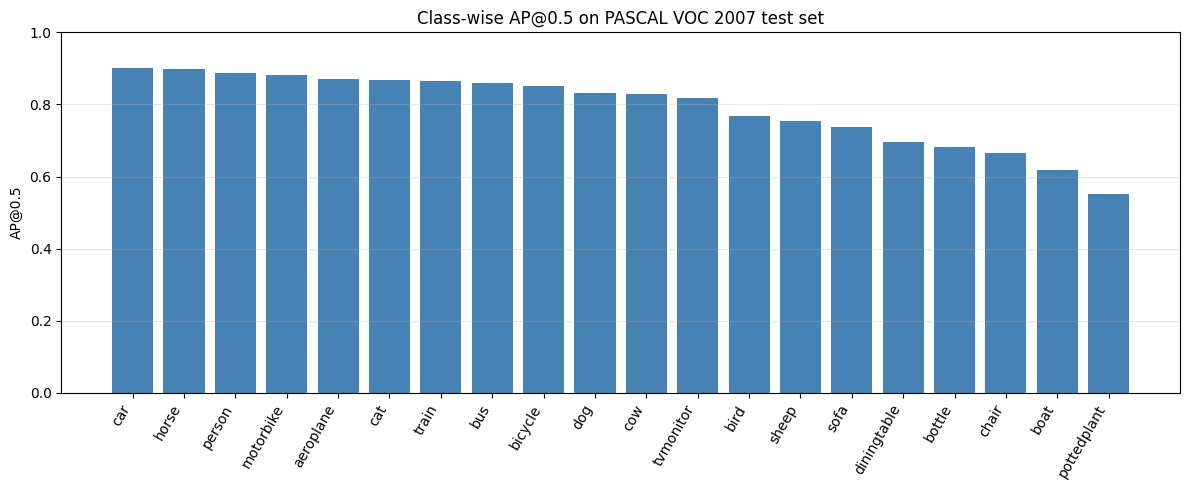

In [ ]:
sorted_ap_table = ap_table.sort_values("AP@0.5", ascending=False).reset_index(drop=True)
print(f"Final test mAP@0.5: {map_50:.4f} ({map_50 * 100:.2f}%)")
print("Class-wise AP@0.5 sorted from high to low:")
display(
    sorted_ap_table.style.format(
        {
            "AP@0.5": "{:.3f}",
            "final_recall": "{:.3f}",
            "final_precision": "{:.3f}",
        }
    )
)

plt.figure(figsize=(12, 5))
plt.bar(sorted_ap_table["class"], sorted_ap_table["AP@0.5"], color="steelblue")
plt.xticks(rotation=60, ha="right")
plt.ylim(0, 1.0)
plt.ylabel("AP@0.5")
plt.title("Class-wise AP@0.5 on PASCAL VOC 2007 test set")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


#### Class-wise Performance Analysis

The class-wise AP@0.5 results show a clear performance gap across categories. The best-performing classes are **car (0.900)**, **horse (0.897)**, **person (0.887)**, **motorbike (0.882)**, and **aeroplane (0.870)**. These categories generally have more distinctive global shapes and often appear at medium or large scales, making them easier for the detector to localise and classify reliably.

In contrast, the weakest categories are **pottedplant (0.552)**, **boat (0.618)**, **chair (0.666)**, **bottle (0.682)**, and **diningtable (0.696)**. These classes are harder for several reasons. First, objects such as bottles and potted plants are often small in the image, which makes proposal generation and box regression more difficult. Second, indoor categories such as chair and diningtable often appear in cluttered scenes and can look visually similar to surrounding furniture, increasing both missed detections and class confusion. Third, boats frequently appear under large viewpoint and scale variation, which can make both localisation and recognition less stable.

The overall **test mAP@0.5 of 0.7915** indicates that the detector performs strongly on VOC 2007 overall, but the category-level breakdown shows that small objects, cluttered scenes, and visually ambiguous classes remain the main sources of difficulty. The stronger performance on classes such as **car**, **horse**, and **person** is also consistent with the design choices in Task 1, especially the use of pretrained multi-scale FPN features and VOC-specific fine-tuning, which are effective for medium-to-large objects with clearer structure. By contrast, the weaker results on **pottedplant**, **bottle**, and **chair** suggest that, although the customised anchors improved scale coverage, small-object detection and cluttered-scene discrimination remain challenging and require further analysis in the following failure-case study.

### Task 2 code section 3: visualization helper

This section draws ground-truth and predicted boxes for one image.

In [ ]:
def visualize_prediction(image_id, ground_truth, prediction, score_threshold=0.50):
    image_path = os.path.join(IMAGE_DIR, f"{image_id:06d}.jpg")
    image_pil = Image.open(image_path).convert("RGB")

    fig, ax = plt.subplots(1, figsize=(12, 8))
    ax.imshow(image_pil)

    for box, label in zip(ground_truth["boxes"], ground_truth["labels"]):
        xmin, ymin, xmax, ymax = box.tolist()
        class_name = IDX_TO_CLASS[int(label.item())]
        rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, linewidth=2, edgecolor="green", facecolor="none")
        ax.add_patch(rect)
        ax.text(xmin, ymin - 5, f"GT: {class_name}", color="green", fontsize=10, bbox=dict(facecolor="white", alpha=0.7))

    keep = prediction["scores"] >= score_threshold
    pred_boxes = prediction["boxes"][keep]
    pred_labels = prediction["labels"][keep]
    pred_scores = prediction["scores"][keep]

    for box, label, score in zip(pred_boxes, pred_labels, pred_scores):
        xmin, ymin, xmax, ymax = box.tolist()
        class_name = IDX_TO_CLASS[int(label.item())]
        rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, linewidth=2, edgecolor="red", facecolor="none", linestyle="--")
        ax.add_patch(rect)
        ax.text(xmin, ymax + 12, f"Pred: {class_name} {float(score):.2f}", color="red", fontsize=10, bbox=dict(facecolor="white", alpha=0.7))

    ax.set_title(f"Image ID: {image_id:06d}")
    ax.axis("off")
    plt.show()


#### Visualisation Setup

The `visualize_prediction` function renders ground-truth and predicted bounding boxes on the same image for direct comparison. **Green solid boxes** indicate ground-truth object locations with their category labels. **Red dashed boxes** indicate model predictions that exceed the confidence threshold of 0.50, annotated with the predicted class name and score. Images where the model performs correctly are not selected; only failure cases are shown in the next section.

### Task 2 code section 4: failure-case classification

This section scores each image by common error types.

In [ ]:
def classify_failure_case(prediction, ground_truth, score_threshold=0.50, iou_threshold=0.50):
    keep = prediction["scores"] >= score_threshold
    pred_boxes = prediction["boxes"][keep]
    pred_labels = prediction["labels"][keep]
    gt_boxes = ground_truth["boxes"]
    gt_labels = ground_truth["labels"]

    matched_gt = set()
    matched_pred = set()
    localization_error = 0
    class_confusion = 0

    if len(pred_boxes) > 0 and len(gt_boxes) > 0:
        ious = box_iou(pred_boxes, gt_boxes)

        for pred_index in range(len(pred_boxes)):
            same_class_mask = gt_labels == pred_labels[pred_index]
            if same_class_mask.any():
                same_class_indices = torch.where(same_class_mask)[0]
                same_class_ious = ious[pred_index][same_class_mask]
                best_same_iou, same_position = torch.max(same_class_ious, dim=0)
                gt_index = int(same_class_indices[int(same_position.item())].item())

                if best_same_iou.item() >= iou_threshold and gt_index not in matched_gt:
                    matched_gt.add(gt_index)
                    matched_pred.add(pred_index)
                elif 0.10 <= best_same_iou.item() < iou_threshold:
                    localization_error += 1

            best_any_iou, best_any_index = torch.max(ious[pred_index], dim=0)
            best_any_index = int(best_any_index.item())
            if best_any_iou.item() >= iou_threshold and pred_labels[pred_index] != gt_labels[best_any_index]:
                class_confusion += 1

    missed_detection = len(gt_boxes) - len(matched_gt)
    false_positive = len(pred_boxes) - len(matched_pred)

    small_or_clutter = 0
    if len(gt_boxes) > 0:
        gt_areas = (gt_boxes[:, 2] - gt_boxes[:, 0]) * (gt_boxes[:, 3] - gt_boxes[:, 1])
        small_objects = int((gt_areas < 32 * 32).sum().item())
        cluttered_scene = len(gt_boxes) >= 5
        small_or_clutter = small_objects + int(cluttered_scene)

    categories = []
    if missed_detection > 0:
        categories.append("missed detection")
    if false_positive > 0:
        categories.append("false positive")
    if localization_error > 0:
        categories.append("localization error")
    if class_confusion > 0:
        categories.append("class confusion")
    if small_or_clutter > 0:
        categories.append("small object / occlusion / cluttered background issue")

    total_errors = missed_detection + false_positive + localization_error + class_confusion + small_or_clutter
    return {
        "image_id": prediction["image_id"],
        "missed_detection": missed_detection,
        "false_positive": false_positive,
        "localization_error": localization_error,
        "class_confusion": class_confusion,
        "small_or_occlusion_or_clutter": small_or_clutter,
        "total_error_score": total_errors,
        "error_categories": "; ".join(categories) if categories else "none",
    }


#### Failure Case Classification

The `classify_failure_case` function assigns each test image one or more error categories based on a systematic comparison of predictions against ground truth. Five error types are tracked:

**Missed detection** — a ground-truth object has no matching prediction with IoU ≥ 0.5 and the correct class label. This typically indicates that the RPN failed to propose a region, or the classifier rejected a valid proposal.

**False positive** — a prediction has no matching ground-truth box at IoU ≥ 0.5. This includes both background detections and duplicated boxes covering the same object.

**Localisation error** — a prediction matches the correct class but its IoU with the best-matching ground-truth box falls between 0.10 and 0.50. The object is found but the box is imprecise.

**Class confusion** — a predicted box overlaps a ground-truth box at IoU ≥ 0.5 but is assigned the wrong category label.

**Small object / occlusion / cluttered scene** — flagged when the image contains ground-truth boxes smaller than 32×32 pixels, or five or more objects in a single image. These conditions are associated with increased difficulty independent of the model's specific errors.

Each image receives a total error score summing all five counts. The five images with the highest scores are selected as representative failure cases.

### Task 2 code section 5: top failure cases and automatic summary

This section displays five representative errors and generates a compact written summary.

Five representative failure cases and their error categories:


,image_id,missed_detection,false_positive,localization_error,class_confusion,small_or_occlusion_or_clutter,total_error_score,error_categories
0,005771,20,1,1,0,29,51,missed detection; false positive; localization...
1,007741,15,7,2,3,19,46,missed detection; false positive; localization...
2,004827,22,2,0,1,17,42,missed detection; false positive; class confus...
3,006471,16,4,2,0,20,42,missed detection; false positive; localization...
4,005633,3,34,1,0,1,39,missed detection; false positive; localization...


Failure case 005771: missed detection; false positive; localization error; small object / occlusion / cluttered background issue


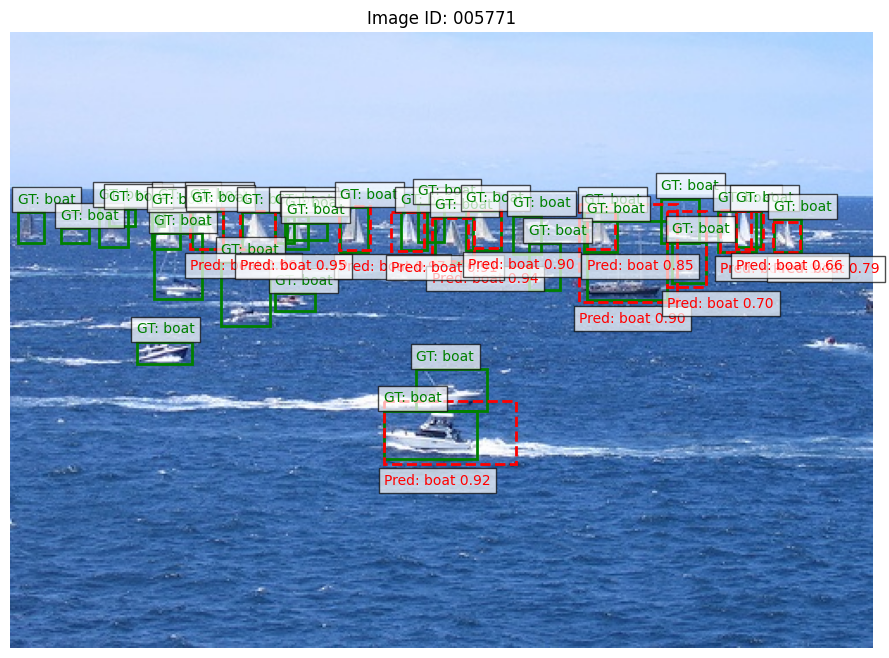

Failure case 007741: missed detection; false positive; localization error; class confusion; small object / occlusion / cluttered background issue


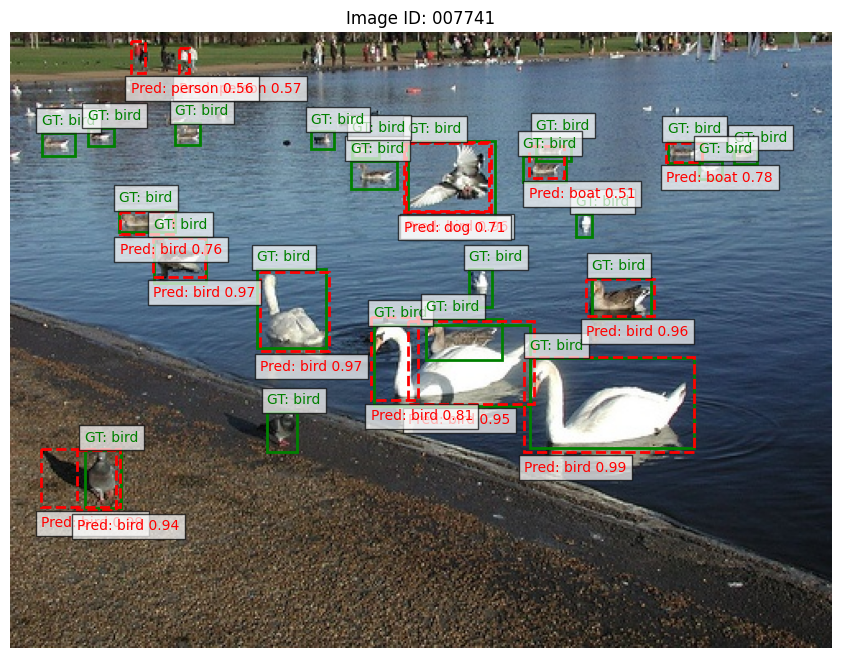

Failure case 004827: missed detection; false positive; class confusion; small object / occlusion / cluttered background issue


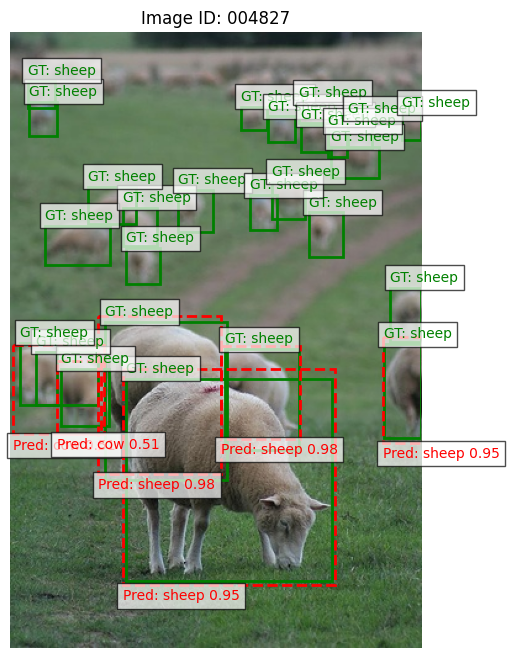

Failure case 006471: missed detection; false positive; localization error; small object / occlusion / cluttered background issue


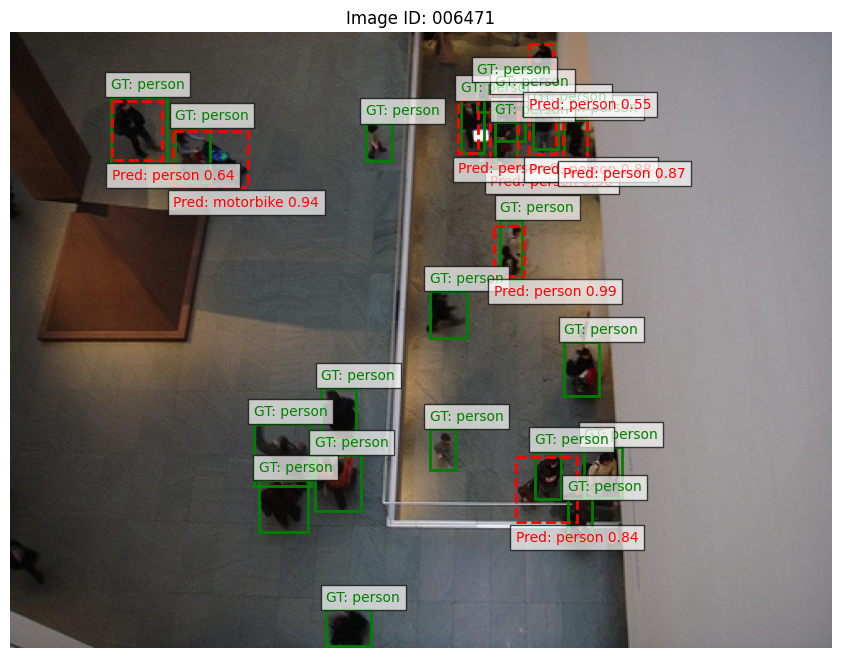

Failure case 005633: missed detection; false positive; localization error; small object / occlusion / cluttered background issue


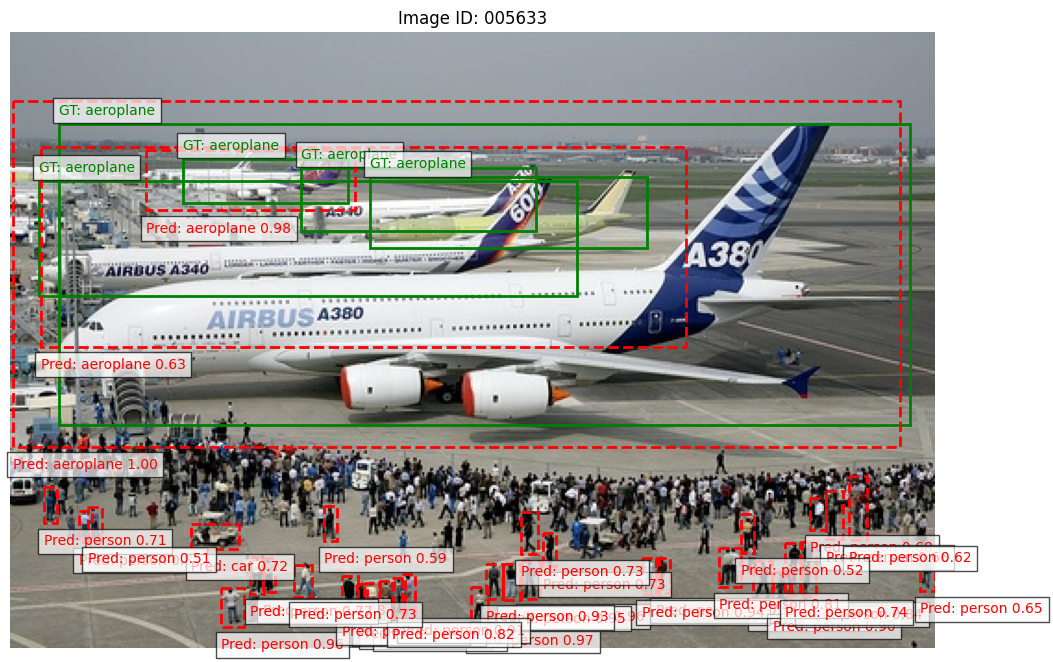


### Automatic performance summary

The final test **mAP@0.5 is 0.7915 (79.15%)**, and this value is reported using the checkpoint selected by the **best validation mAP@0.5** rather than the final training epoch by default.

The strongest classes in this run are **car, horse, person, motorbike, aeroplane**, and the weakest classes are **diningtable, bottle, chair, boat, pottedplant**.

The failure visualizations use green boxes for ground truth and red dashed boxes for predictions with confidence >= 0.50. Each selected case is labelled with one or more error categories: missed detection, false positive, localization error, class confusion, or small object / occlusion / cluttered background issue.


In [ ]:
failure_summaries = []
for prediction, ground_truth in zip(predictions, ground_truths):
    summary = classify_failure_case(prediction, ground_truth, PRED_SCORE_THRESHOLD, IOU_THRESHOLD)
    if summary["total_error_score"] > 0:
        failure_summaries.append(summary)

failure_summaries = sorted(
    failure_summaries,
    key=lambda row: (-row["total_error_score"], row["image_id"])
)
failure_table = pd.DataFrame(failure_summaries[:5]).copy()
failure_table["image_id"] = failure_table["image_id"].apply(lambda value: f"{value:06d}")

print("Five representative failure cases and their error categories:")
display(failure_table)

for row in failure_summaries[:5]:
    image_id = row["image_id"]
    index = next(i for i, gt in enumerate(ground_truths) if gt["image_id"] == image_id)
    print(f"Failure case {image_id:06d}: {row['error_categories']}")
    visualize_prediction(image_id, ground_truths[index], predictions[index], PRED_SCORE_THRESHOLD)

best_classes = sorted_ap_table.head(5)["class"].tolist()
hard_classes = sorted_ap_table.tail(5)["class"].tolist()

display(
    Markdown(
        f"""
### Automatic performance summary

The final test **mAP@0.5 is {map_50:.4f} ({map_50 * 100:.2f}%)**, and this value is reported using the checkpoint selected by the **best validation mAP@0.5** rather than the final training epoch by default.

The strongest classes in this run are **{', '.join(best_classes)}**, and the weakest classes are **{', '.join(hard_classes)}**.

The failure visualizations use green boxes for ground truth and red dashed boxes for predictions with confidence >= {PRED_SCORE_THRESHOLD:.2f}. Each selected case is labelled with one or more error categories: missed detection, false positive, localization error, class confusion, or small object / occlusion / cluttered background issue.
"""
    )
)


#### Failure Case Visualisation

The five images above are selected as the most representative failure cases based on total error score. In each image, **green boxes** show ground-truth object locations and **red dashed boxes** show model predictions with confidence >= 0.50. The error category label printed above each image identifies the dominant failure mode for that case, and the table preceding the images provides the full breakdown of error counts.

Across the five representative failure cases, the visual evidence matches the quantitative error summary closely. **Image 005771** has the highest total error score and shows a heavily cluttered scene with many objects, leading to extensive missed detections as well as a few inaccurate predicted boxes. **Image 007741** contains overlapping objects and visually similar categories, which explains the coexistence of missed detections, false positives, localisation errors, and class confusion. **Image 004827** is dominated by missed detections, suggesting that several ground-truth objects are either too small, partially occluded, or not sufficiently covered by the proposal stage. **Image 006471** shows that the detector can often identify the approximate object region but still fail to align the predicted box tightly enough to satisfy the IoU threshold, resulting in localisation errors. **Image 005633** is the clearest false-positive case, where repeated background structures or ambiguous visual patterns appear to trigger overly confident but incorrect detections.

### Error Analysis and Discussion

#### Observed Error Patterns

The five representative failure cases confirm the main weaknesses already suggested by the class-wise AP results. In particular, categories with relatively low AP such as **pottedplant, bottle, chair, boat, and diningtable** are strongly associated with small object size, cluttered backgrounds, or visually confusing scene structure.

**Missed detections** are the most common failure type across the selected cases. This pattern is especially clear in **images 005771, 004827, and 006471**, where many ground-truth objects are not successfully detected. In these scenes, small object size, partial occlusion, and dense object layout all make proposal generation and confidence scoring more difficult.

**False positives** are also significant, most notably in **image 005633**, where many incorrect detections are produced. This suggests that some background regions or repeated structures share enough visual similarity with object categories to trigger overly confident predictions.

**Localisation errors** appear in cases such as **006471** and **007741**, indicating that the detector often identifies the approximate object region but does not place the bounding box tightly enough to exceed the IoU = 0.5 threshold.

**Class confusion** is less frequent than missed detections, but it is still visible in difficult scenes such as **007741** and **004827**, where overlapping objects or similar category appearance make recognition harder.

Overall, the failure cases show that the detector is strong on clear medium-to-large objects, but remains less reliable on small instances, crowded scenes, and visually ambiguous categories.

#### Potential Improvements

The proposed improvements are directly motivated by the observed failure patterns. Since missed detections are most common for small-object categories such as **bottle** and **pottedplant**, one practical improvement would be to use higher-resolution training or introduce even smaller anchors to improve proposal recall.

Since representative cases such as **005633** contain many false positives, a stricter inference setting could also help. Increasing the score threshold or adjusting NMS could suppress low-quality duplicate detections and reduce spurious predictions on background regions.

To improve localisation quality, longer fine-tuning or a stronger box regression objective could help the detector fit object boundaries more accurately, especially in cases like **006471** where the predicted region is close to correct but still fails the IoU threshold.

To reduce class confusion in cluttered scenes, class-balanced sampling and richer augmentation could improve category discrimination, especially for visually similar indoor objects such as **chair** and **diningtable**.

These improvements are therefore not generic suggestions, but targeted responses to the specific weaknesses observed in the current model’s class-wise results and failure-case visualisations.